# Predicting TP53 Mutation Status from Gene Expression — TCGA Pan-Cancer Analysis

This notebook is the main project report for the TCGA dataset. It is written as a step-by-step analysis, starting from raw data exploration through to model evaluation.

**Biological question:** Can we predict whether a tumour carries a TP53 mutation — and if so, what *type* of mutation — using only RNA-seq gene expression data?

**Why this matters:** TP53 is the most frequently mutated gene in human cancer (~50% of all tumours). As a master transcription factor, a TP53 mutation leaves a measurable downstream signature in the expression of hundreds of target genes. If a classifier can learn this signature, it opens the door to non-invasive mutation prediction from transcriptomics.

## Running Note

Run cells top to bottom. Later cells reuse variables and dataframes created earlier. Model training results were generated by `scripts/03_train_binary.py` and are loaded from pre-computed files — training runs in the background scripts to keep this notebook fast and reproducible. All paths are relative to the project root.

## Step 0: Setup

In [70]:
from pathlib import Path
import os
import sys
import warnings

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import joblib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tp53_ml.config import load_config
from tp53_ml.genes import CANONICAL_P53_TARGETS_INFO, P53_PATHWAY_GENES
from tp53_ml.preprocessing import TopVarianceSelector

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

cfg = load_config("config/project.yaml")
RANDOM_STATE = cfg["project"]["random_state"]

TCGA_DIR = Path("data/processed/tcga")
Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("reports/tables").mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("TCGA processed dir:", TCGA_DIR)

Project root: /Users/markostamenovic/Desktop/MSc CLASSES/ML Lab/TP53-MUTATIONS
TCGA processed dir: data/processed/tcga


## Step 1: Choosing a Dataset — CCLE or TCGA?

Two candidate datasets are available for this project:

| | **CCLE / DepMap** | **TCGA** |
|---|---|---|
| Sample type | Cancer cell lines | Primary tumours |
| Size | ~1,700 samples | ~11,000 samples |
| Expression units | log2(TPM + 1) | RSEM |
| Cancer types | ~30 lineages | 33 cancer types |
| TP53 balance | 58% mutant / 42% WT | 32% mutant / 68% WT |
| Minority class sizes | Frameshift: 58, Nonsense: 113 | Frameshift: 401, Nonsense: 444 |

**CCLE pros:** Clean, well-curated, consistent processing, easy programmatic access. Cell lines are a standard benchmark in cancer ML.

**CCLE cons:** Fewer samples. Cell lines have adapted to in vitro conditions and diverged from original tumour biology. Very few samples for rare mutation types (58 Frameshifts) — too few for reliable multiclass prediction.

**TCGA pros:** Far more data. Primary tumour samples represent real patient biology. Frameshift and Nonsense samples are 5–7× more abundant — sufficient for multiclass learning.

**TCGA cons:** Pan-cancer dataset — cancer type is the dominant axis of variation, not TP53 status. RSEM normalisation differs from CCLE (cannot mix the two). Real tumour samples contain confounders: tumour purity, immune infiltration, co-occurring mutations.

In [71]:
# Load both datasets for side-by-side comparison
ccle_labels = pd.read_csv("data/processed/tp53_labels.csv")
tcga_labels = pd.read_csv(TCGA_DIR / "tp53_labels.csv")

# Expression sizes (read only headers — no need to load full matrices)
ccle_X_cols = pd.read_csv("data/processed/expression_matched.csv.gz", index_col=0, nrows=0).shape[1]
tcga_X_cols = pd.read_csv(TCGA_DIR / "expression_matched.csv.gz", index_col=0, nrows=0).shape[1]

comparison = pd.DataFrame([
    {"metric": "Total samples",        "CCLE": ccle_labels.shape[0],  "TCGA": tcga_labels.shape[0]},
    {"metric": "Expression genes",     "CCLE": ccle_X_cols,           "TCGA": tcga_X_cols},
    {"metric": "TP53 mutant",          "CCLE": int(ccle_labels["tp53_mutant"].sum()),
                                        "TCGA": int(tcga_labels["tp53_mutant"].sum())},
    {"metric": "TP53 wild-type",       "CCLE": int((ccle_labels["tp53_mutant"]==0).sum()),
                                        "TCGA": int((tcga_labels["tp53_mutant"]==0).sum())},
    {"metric": "Mutant fraction (%)",  "CCLE": round(ccle_labels["tp53_mutant"].mean()*100,1),
                                        "TCGA": round(tcga_labels["tp53_mutant"].mean()*100,1)},
    {"metric": "Frameshift samples",   "CCLE": int((ccle_labels["mutation_type_collapsed"]=="Frameshift").sum()),
                                        "TCGA": int((tcga_labels["mutation_type_collapsed"]=="Frameshift").sum())},
    {"metric": "Nonsense samples",     "CCLE": int((ccle_labels["mutation_type_collapsed"]=="Nonsense").sum()),
                                        "TCGA": int((tcga_labels["mutation_type_collapsed"]=="Nonsense").sum())},
    {"metric": "Splice samples",       "CCLE": int((ccle_labels["mutation_type_collapsed"]=="Splice").sum()),
                                        "TCGA": int((tcga_labels["mutation_type_collapsed"]=="Splice").sum())},
])
comparison

,metric,CCLE,TCGA
0,Total samples,1719.0000,9701.0000
1,Expression genes,19215.0000,20281.0000
2,TP53 mutant,997.0000,3130.0000
3,TP53 wild-type,722.0000,6571.0000
4,Mutant fraction (%),58.0000,32.3000
5,Frameshift samples,58.0000,401.0000
6,Nonsense samples,113.0000,444.0000
7,Splice samples,0.0000,215.0000


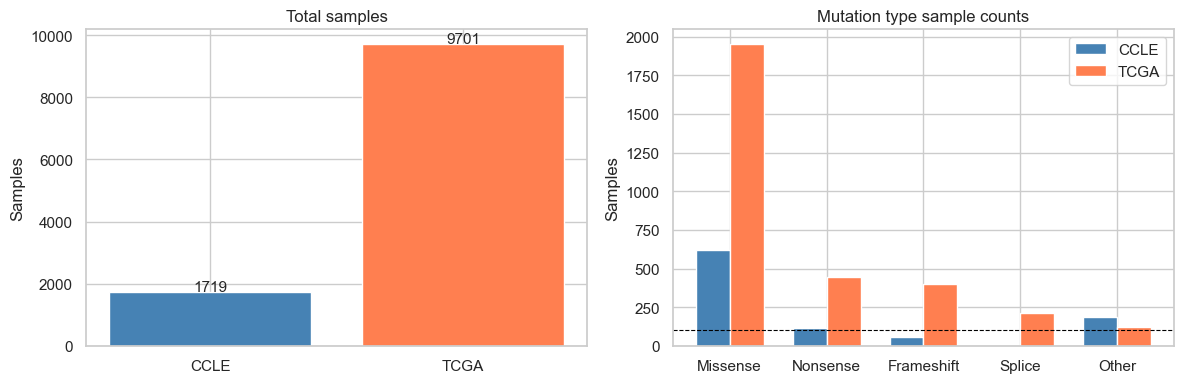

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sample size comparison
axes[0].bar(["CCLE", "TCGA"], [ccle_labels.shape[0], tcga_labels.shape[0]],
            color=["steelblue", "coral"])
axes[0].set_title("Total samples")
axes[0].set_ylabel("Samples")
for i, v in enumerate([ccle_labels.shape[0], tcga_labels.shape[0]]):
    axes[0].text(i, v + 50, str(v), ha="center", fontsize=11)

# Minority class sizes
classes = ["Missense", "Nonsense", "Frameshift", "Splice", "Other"]
ccle_counts = [int((ccle_labels["mutation_type_collapsed"]==c).sum()) for c in classes]
tcga_counts = [int((tcga_labels["mutation_type_collapsed"]==c).sum()) for c in classes]
x = np.arange(len(classes))
w = 0.35
axes[1].bar(x - w/2, ccle_counts, w, label="CCLE", color="steelblue")
axes[1].bar(x + w/2, tcga_counts, w, label="TCGA", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_title("Mutation type sample counts")
axes[1].set_ylabel("Samples")
axes[1].legend()
axes[1].axhline(100, color="black", linestyle="--", linewidth=0.8, label="Min viable (100)")

plt.tight_layout()
plt.show()

**Decision: We use TCGA.** The minority class sizes in CCLE (Frameshift: 58, Nonsense: 113, Splice: 0) are below the minimum threshold for reliable multiclass learning. TCGA provides 5–7× more samples for each rare class and a much larger overall dataset. The tradeoff is added noise from pan-cancer heterogeneity, which we will characterise in the data quality section below.

**Important: we do not mix the two datasets.** CCLE uses TPM normalisation (mean expression ~2.6) while TCGA uses RSEM (mean ~6.5). Combining them without correction would teach the model to distinguish datasets rather than TP53 biology.

## Step 2: Load the TCGA Dataset

TCGA data was downloaded from UCSC Xena and processed by `scripts/00_download_tcga.py` and `scripts/01_build_tcga_dataset.py`. Processing steps:
- Kept only **Primary Tumor** samples (removed normal tissue, metastatic, recurrent)
- Transposed expression matrix to samples × genes
- Dropped 29 non-gene numeric columns (internal Xena IDs)
- Filled NaN with 0 (sparse RSEM matrix)
- Extracted TP53 mutation labels and collapsed rare types into 'Other'

In [73]:
print("Loading TCGA expression matrix (this may take ~30s) …")
X      = pd.read_csv(TCGA_DIR / "expression_matched.csv.gz", index_col=0)
labels = pd.read_csv(TCGA_DIR / "tp53_labels.csv")
meta   = pd.read_csv(TCGA_DIR / "sample_metadata.csv")

print(f"Expression matrix: {X.shape[0]:,} samples × {X.shape[1]:,} genes")
print(f"Labels: {labels.shape}")
print(f"Metadata: {meta.shape}")
print(f"NaN values: {X.isnull().sum().sum():,}")
print(f"Mean expression: {X.values.mean():.3f}")

Loading TCGA expression matrix (this may take ~30s) …
Expression matrix: 9,701 samples × 20,281 genes
Labels: (9701, 4)
Metadata: (9701, 3)
NaN values: 0
Mean expression: 6.477


In [74]:
# Build analysis_df — single dataframe for all EDA
analysis_df = labels.set_index("sample_id").copy()
analysis_df["tp53_status"] = analysis_df["tp53_mutant"].map({0: "WT", 1: "Mutant"})
analysis_df["lineage"] = meta.set_index("sample_id")["primary_disease"]
analysis_df.index = X.index

analysis_df[["tp53_status", "mutation_type_collapsed", "lineage"]].head()

,tp53_status,mutation_type_collapsed,lineage
sample_id,,,
TCGA-OR-A5J1-01,WT,WT,adrenocortical cancer
TCGA-OR-A5J2-01,Mutant,Frameshift,adrenocortical cancer
TCGA-OR-A5J3-01,WT,WT,adrenocortical cancer
TCGA-OR-A5J5-01,Mutant,Missense,adrenocortical cancer
TCGA-OR-A5J6-01,WT,WT,adrenocortical cancer


## Step 3: Data Quality Analysis

Before any modelling, we need to understand what we are working with. TCGA is a pan-cancer dataset with real tumour samples — it will be noisier than CCLE cell lines. The analyses below check four quality dimensions:

1. **Sample-level sparsity** — do mutant and WT samples differ in zero-expression rates?
2. **Gene-level sparsity** — are some genes consistently zero in one group but not the other?
3. **Outlier detection** — are there samples with unusual expression profiles?
4. **Canonical p53 target genes** — is the TP53 transcriptional signal actually present in the data?

### 3a. Data Audit

In [75]:
audit = pd.DataFrame([
    {"metric": "samples",                  "value": X.shape[0]},
    {"metric": "genes",                    "value": X.shape[1]},
    {"metric": "missing_expression_values","value": int(X.isna().sum().sum())},
    {"metric": "duplicated_gene_names",    "value": int(pd.Index(X.columns).duplicated().sum())},
    {"metric": "mutant_samples",           "value": int((analysis_df["tp53_mutant"]==1).sum())},
    {"metric": "wt_samples",              "value": int((analysis_df["tp53_mutant"]==0).sum())},
    {"metric": "cancer_types",             "value": int(analysis_df["lineage"].nunique())},
    {"metric": "mean_expression",          "value": round(float(X.values.mean()), 3)},
])
audit

,metric,value
0,samples,9701.0000
1,genes,20281.0000
2,missing_expression_values,0.0000
3,duplicated_gene_names,0.0000
4,mutant_samples,3130.0000
5,wt_samples,6571.0000
6,cancer_types,32.0000
7,mean_expression,6.4770


### 3b. Sample-Level Sparsity

Sparsity is the fraction of zero or near-zero expression values per sample. In RSEM-normalised data, exact zeros usually mean the gene had no detected reads. We check whether TP53 mutant and WT samples differ in their global sparsity — if they do, the model may exploit data quality differences rather than biology.

Sparsity — Mutant: 0.130 ± 0.023
Sparsity — WT:     0.139 ± 0.025
Mann-Whitney U = 8191178,  p = 3.28e-59


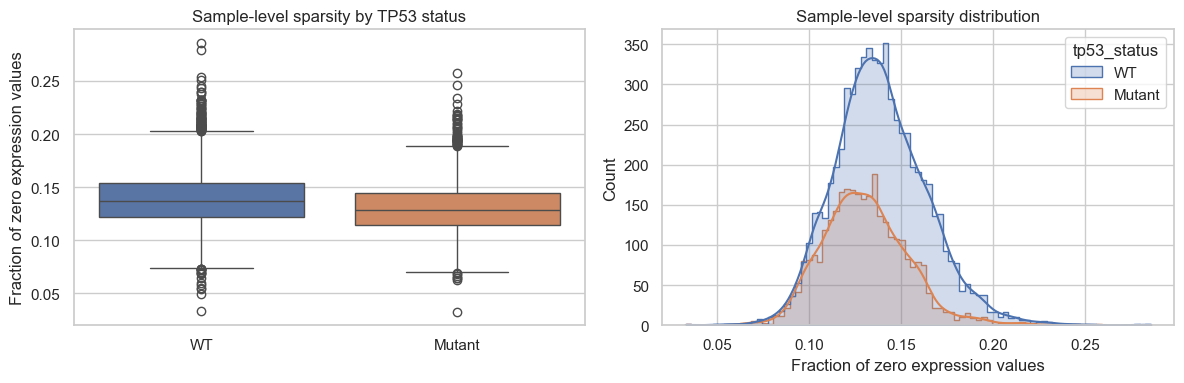

In [76]:
zero_mask = X <= 0.0
sample_sparsity = zero_mask.mean(axis=1)

sparsity_df = analysis_df[["tp53_status", "tp53_mutant", "lineage"]].copy()
sparsity_df["sample_sparsity"] = sample_sparsity.values

mut_s = sparsity_df.loc[sparsity_df["tp53_mutant"]==1, "sample_sparsity"]
wt_s  = sparsity_df.loc[sparsity_df["tp53_mutant"]==0, "sample_sparsity"]
u_stat, p_val = mannwhitneyu(mut_s, wt_s, alternative="two-sided")

print(f"Sparsity — Mutant: {mut_s.mean():.3f} ± {mut_s.std():.3f}")
print(f"Sparsity — WT:     {wt_s.mean():.3f} ± {wt_s.std():.3f}")
print(f"Mann-Whitney U = {u_stat:.0f},  p = {p_val:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=sparsity_df, x="tp53_status", y="sample_sparsity",
            hue="tp53_status", legend=False, ax=axes[0])
axes[0].set_title("Sample-level sparsity by TP53 status")
axes[0].set_xlabel("")
axes[0].set_ylabel("Fraction of zero expression values")

sns.histplot(data=sparsity_df, x="sample_sparsity", hue="tp53_status",
             kde=True, element="step", ax=axes[1])
axes[1].set_title("Sample-level sparsity distribution")
axes[1].set_xlabel("Fraction of zero expression values")

plt.tight_layout()
plt.show()

**Interpretation — Sample-Level Sparsity:**

WT samples have slightly more zero expression values than TP53-mutant samples.

How it helps modelling: it warns us that the model may learn technical sparsity patterns, not true TP53 biology. Zero percentage could be predictive, but it may reflect batch effects, sequencing depth, tissue type, or preprocessing rather than TP53 function. We should check whether this sparsity difference remains within cancer types or batches.

**Main modelling lesson:** do not let the classifier succeed only because mutant and WT samples differ in global data quality.

### 3c. Gene-Level Sparsity

Gene-level sparsity asks how often each gene is zero across samples. A large difference between mutant and WT samples suggests that gene could be predictive — but the difference may also reflect tissue composition or dataset imbalance rather than TP53 biology.

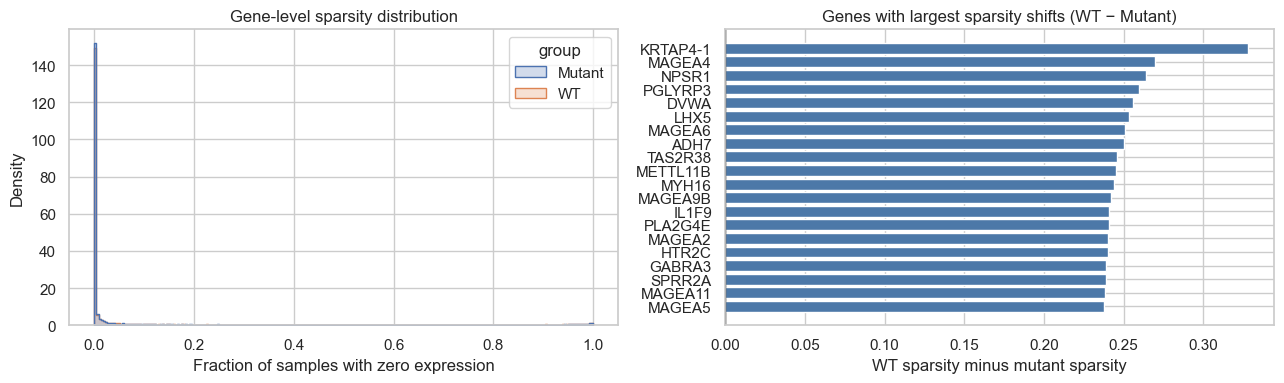

In [77]:
gene_sparsity_mut = zero_mask.loc[analysis_df["tp53_mutant"]==1].mean(axis=0)
gene_sparsity_wt  = zero_mask.loc[analysis_df["tp53_mutant"]==0].mean(axis=0)

gene_sparsity_df = pd.DataFrame({
    "gene":            X.columns,
    "sparsity_mutant": gene_sparsity_mut.values,
    "sparsity_wt":     gene_sparsity_wt.values,
})
gene_sparsity_df["shift_wt_minus_mutant"] = (
    gene_sparsity_df["sparsity_wt"] - gene_sparsity_df["sparsity_mutant"]
)
gene_sparsity_df = gene_sparsity_df.sort_values("shift_wt_minus_mutant", ascending=False, key=abs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_df = pd.concat([
    pd.DataFrame({"sparsity": gene_sparsity_mut.values, "group": "Mutant"}),
    pd.DataFrame({"sparsity": gene_sparsity_wt.values,  "group": "WT"}),
], ignore_index=True)
sns.histplot(data=plot_df, x="sparsity", hue="group",
             element="step", stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Gene-level sparsity distribution")
axes[0].set_xlabel("Fraction of samples with zero expression")

top_shift = gene_sparsity_df.head(20).iloc[::-1]
colors = np.where(top_shift["shift_wt_minus_mutant"] >= 0, "#4C78A8", "#E45756")
axes[1].barh(top_shift["gene"], top_shift["shift_wt_minus_mutant"], color=colors)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Genes with largest sparsity shifts (WT − Mutant)")
axes[1].set_xlabel("WT sparsity minus mutant sparsity")

plt.tight_layout()
plt.show()

**Interpretation — Gene-Level Sparsity:**

Most genes are non-zero in most samples, but some genes are zero in many samples. The largest sparsity shifts plot shows genes that are much more often zero in WT than in mutant samples.

How it helps modelling: it helps decide which genes to remove because they are too sparse to be reliable. Some genes may be useful as binary features (expressed vs not expressed). Genes with large mutant-vs-WT sparsity shifts may be strong predictors — but they could also reflect tissue composition or dataset imbalance.

**Main modelling lesson:** sparsity itself can be informative, but sparse genes need careful filtering and validation.

### 3d. Outlier Detection

Outliers are samples with unusual expression profiles compared to the rest of the dataset. We flag them using three methods:
1. **Isolation Forest on PCA coordinates** — samples in sparse PCA regions
2. **Isolation Forest on row statistics** — samples with unusual mean/std/skew
3. **Mahalanobis distance** — samples far from the multivariate centre in PCA space

A sample is marked a combined outlier if at least 2 of 3 methods flag it.

Outliers flagged: 81 / 9701 (0.8%)


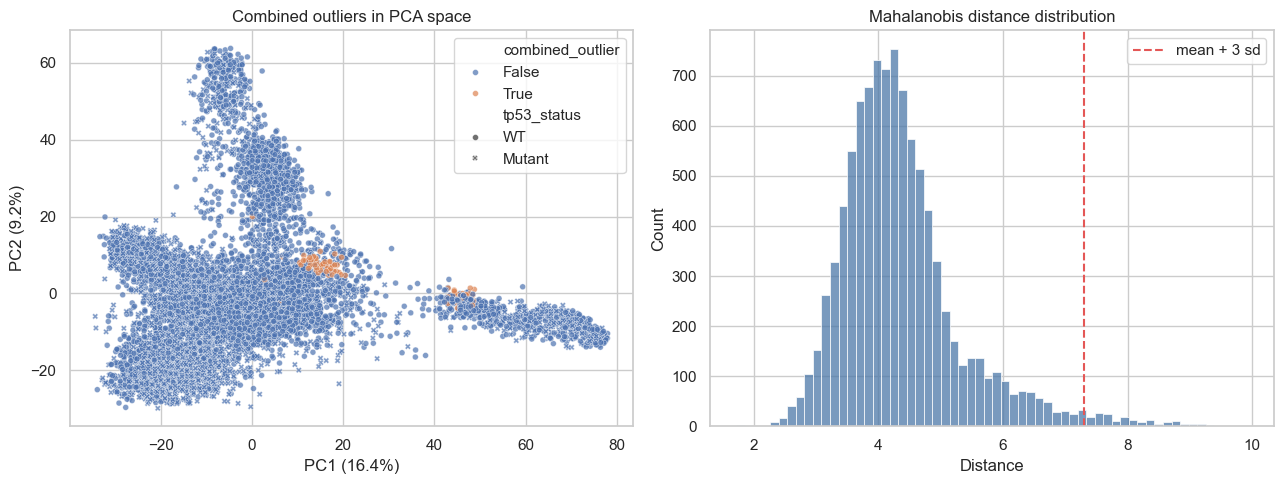

In [78]:
# PCA on top variable genes
selector = TopVarianceSelector(k=3000, min_mean_expression=cfg["features"]["min_mean_expression"])
X_var    = selector.fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_var)

pca = PCA(n_components=50, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)

pca_df = analysis_df[["tp53_status", "tp53_mutant", "mutation_type_collapsed", "lineage"]].copy()
pca_df["PC1"] = pcs[:, 0]
pca_df["PC2"] = pcs[:, 1]

# Row statistics for Isolation Forest
row_stats = pd.DataFrame(index=X.index)
row_stats["mean"]     = X.mean(axis=1)
row_stats["std"]      = X.std(axis=1)
row_stats["zero_pct"] = zero_mask.mean(axis=1)
row_stats["skew"]     = X.skew(axis=1)
row_stats             = row_stats.fillna(0)

contamination = min(0.05, max(1/len(X), 0.01))
outlier_pca   = IsolationForest(n_estimators=100, contamination=contamination,
                                random_state=RANDOM_STATE).fit_predict(pcs[:, :20]) == -1
outlier_stats = IsolationForest(n_estimators=100, contamination=contamination,
                                random_state=RANDOM_STATE).fit_predict(row_stats) == -1

pcs20 = pcs[:, :20]
inv_cov = np.linalg.pinv(np.cov(pcs20, rowvar=False))
centered = pcs20 - pcs20.mean(axis=0)
mahal_dist = np.sqrt(np.sum(centered @ inv_cov * centered, axis=1))
mahal_threshold = mahal_dist.mean() + 3 * mahal_dist.std()
outlier_mahal = mahal_dist > mahal_threshold

combined_outlier = (outlier_pca.astype(int) + outlier_stats.astype(int) + outlier_mahal.astype(int)) >= 2
pca_df["combined_outlier"] = combined_outlier

print(f"Outliers flagged: {combined_outlier.sum()} / {len(X)} ({combined_outlier.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="combined_outlier",
                style="tp53_status", s=18, alpha=0.7, ax=axes[0])
axes[0].set_title("Combined outliers in PCA space")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

sns.histplot(mahal_dist, bins=60, ax=axes[1], color="#4C78A8")
axes[1].axvline(mahal_threshold, color="#E45756", linestyle="--", label="mean + 3 sd")
axes[1].set_title("Mahalanobis distance distribution")
axes[1].set_xlabel("Distance")
axes[1].legend()
plt.tight_layout()
plt.show()

**Interpretation — Outlier Detection:**

The PCA plot and Mahalanobis histogram identify samples that look unusual compared to the rest of the dataset.

How it helps modelling: outliers can strongly affect normalisation, PCA, feature selection, and model coefficients. If outliers are technical artefacts (failed samples, mislabelled tissue), removing them may improve generalisation. If they are real biological subtypes (e.g. a very unusual tumour), removing them could make the model less realistic.

**Main modelling lesson:** handle outliers deliberately. In this analysis we retain all samples but note that a follow-up sensitivity analysis (training with and without flagged outliers) would quantify their impact.

### 3e. Canonical p53 Target Gene Expression

Known p53 target genes (CDKN1A, MDM2, ZMAT3, BAX, DDB2, etc.) should be down-regulated in TP53-mutant samples because wild-type p53 normally activates them. If these genes show no difference between mutant and WT, the dataset likely lacks a meaningful TP53 signal.

**Important caution:** because these plots use TP53 labels, any feature selection based on them should be done inside the training set only. Performing selection on the full dataset before the train/test split is data leakage and inflates reported performance.

Canonical p53 targets present: 16 / 16


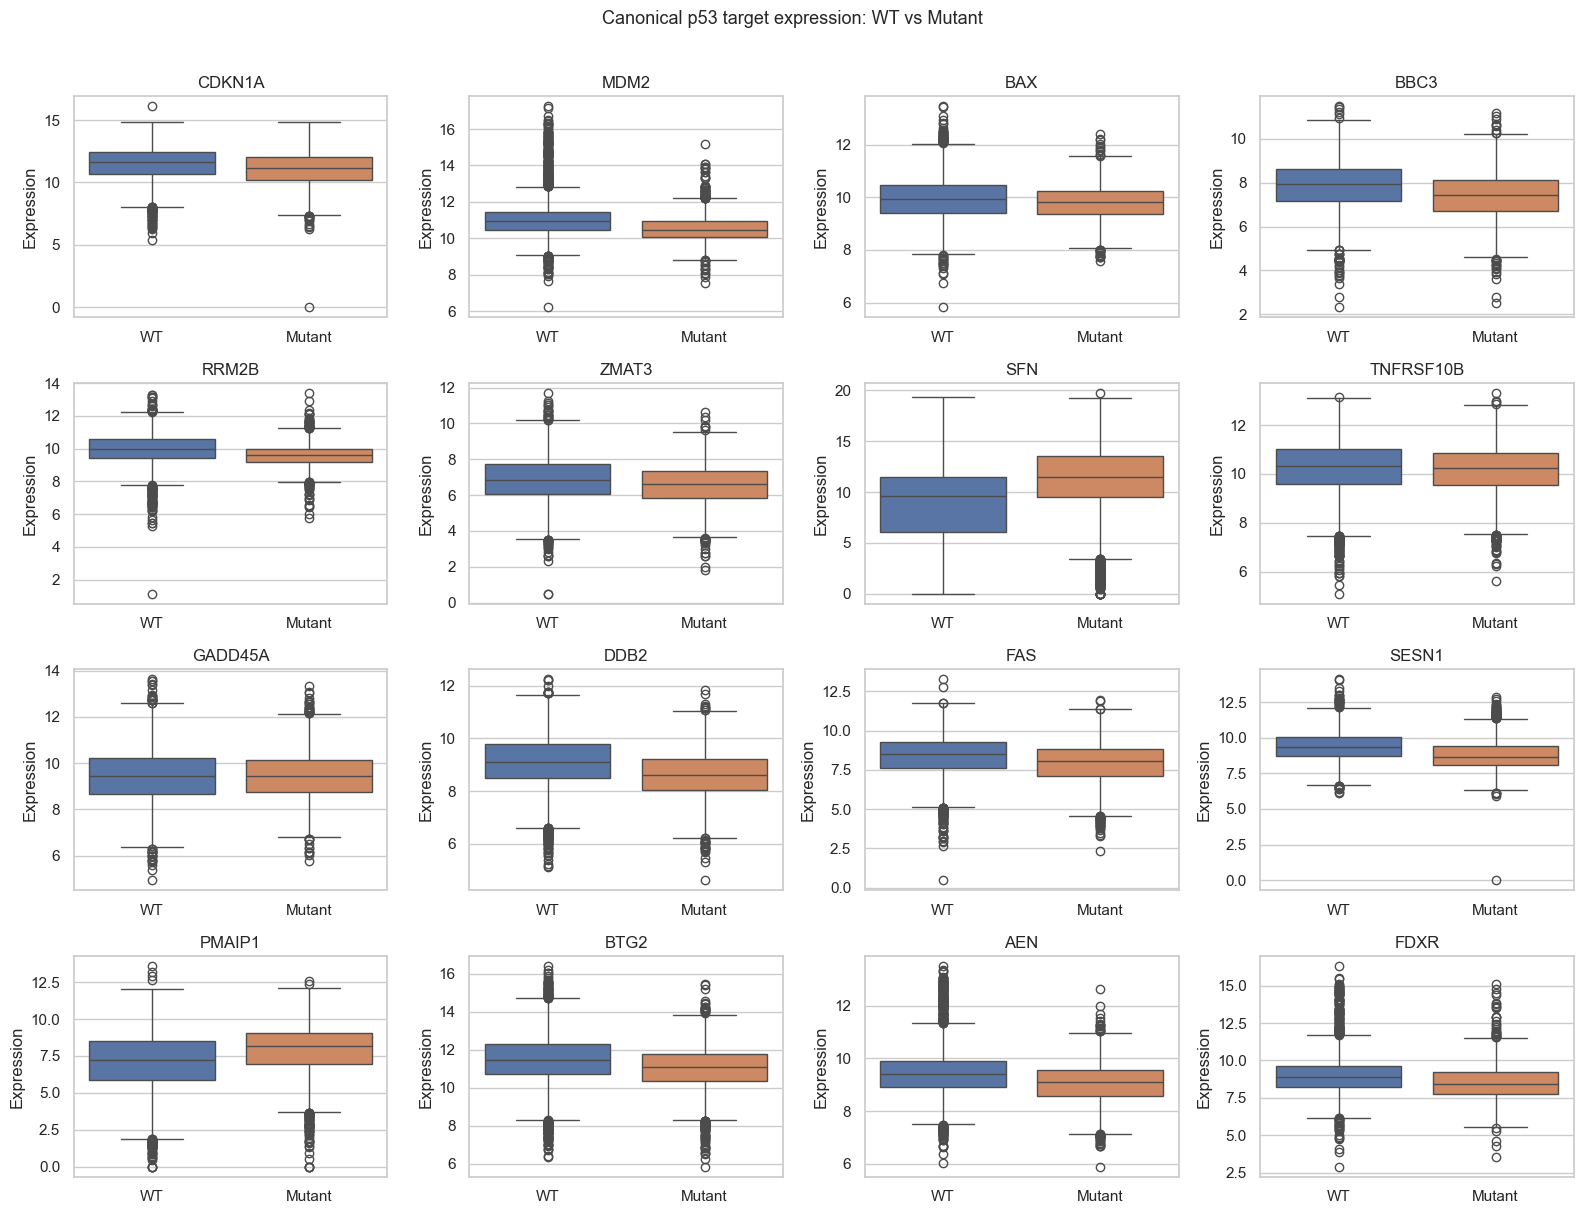

In [79]:
canonical_genes = [g for g in CANONICAL_P53_TARGETS_INFO if g in X.columns]
print(f"Canonical p53 targets present: {len(canonical_genes)} / {len(CANONICAL_P53_TARGETS_INFO)}")

canonical_long = (
    X[canonical_genes]
    .assign(tp53_status=analysis_df["tp53_status"].values,
            tp53_mutant=analysis_df["tp53_mutant"].values)
    .melt(id_vars=["tp53_status", "tp53_mutant"], var_name="gene", value_name="expression")
)

n_cols = 4
n_rows = int(np.ceil(len(canonical_genes) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), squeeze=False)
for ax, gene in zip(axes.ravel(), canonical_genes):
    data = canonical_long.loc[canonical_long["gene"]==gene]
    sns.boxplot(data=data, x="tp53_status", y="expression",
                hue="tp53_status", legend=False, ax=ax)
    ax.set_title(gene)
    ax.set_xlabel("")
    ax.set_ylabel("Expression")
for ax in axes.ravel()[len(canonical_genes):]:
    ax.axis("off")
fig.suptitle("Canonical p53 target expression: WT vs Mutant", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

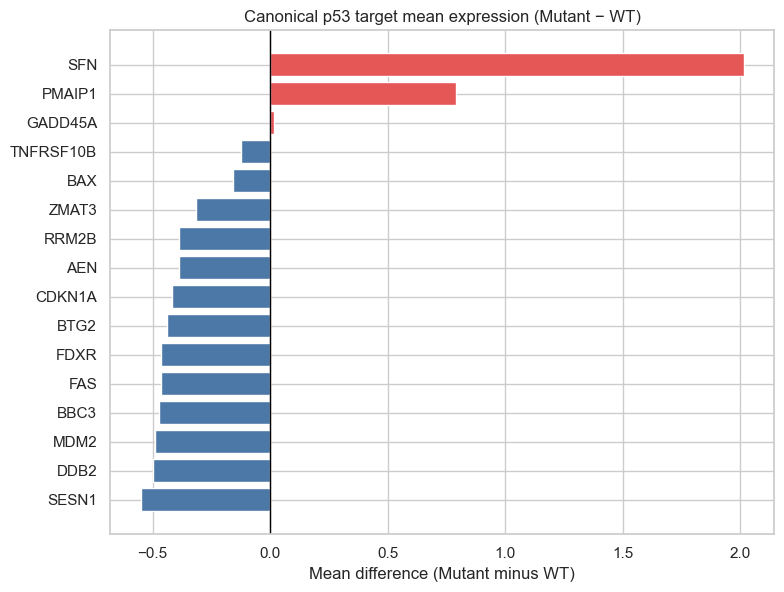

Genes lower in mutant (FDR<0.05): 15 / 16


,gene,known_role,diff_mut_minus_wt,fdr_bh,direction
11,SESN1,antioxidant / mTOR regulation,-0.5513,0.0000,lower in mutant
9,DDB2,nucleotide excision repair,-0.4998,0.0000,lower in mutant
1,MDM2,p53 negative regulator,-0.4879,0.0000,lower in mutant
3,BBC3,pro-apoptotic (PUMA),-0.4726,0.0000,lower in mutant
10,FAS,death receptor / apoptosis,-0.4638,0.0000,lower in mutant
15,FDXR,mitochondrial electron transport,-0.4629,0.0000,lower in mutant
13,BTG2,anti-proliferative,-0.4376,0.0000,lower in mutant
0,CDKN1A,cell cycle arrest (p21),-0.4173,0.0000,lower in mutant
14,AEN,apoptosis enhancing nuclease,-0.3889,0.0000,lower in mutant
4,RRM2B,nucleotide synthesis / DNA repair,-0.3868,0.0000,lower in mutant


In [80]:
def benjamini_hochberg(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adjusted = np.empty(n)
    adjusted[order] = p[order] * n / np.arange(1, n+1)
    adjusted[order] = np.minimum.accumulate(adjusted[order][::-1])[::-1]
    return np.clip(adjusted, 0, 1)

rows = []
for gene in canonical_genes:
    mut_v = X.loc[analysis_df["tp53_mutant"]==1, gene]
    wt_v  = X.loc[analysis_df["tp53_mutant"]==0, gene]
    u, p  = mannwhitneyu(mut_v, wt_v, alternative="two-sided")
    rows.append({"gene": gene, "known_role": CANONICAL_P53_TARGETS_INFO[gene],
                 "mean_mutant": mut_v.mean(), "mean_wt": wt_v.mean(),
                 "diff_mut_minus_wt": mut_v.mean() - wt_v.mean(), "p_value": p})

canon_tests = pd.DataFrame(rows)
canon_tests["fdr_bh"] = benjamini_hochberg(canon_tests["p_value"])
canon_tests["direction"] = np.where(canon_tests["diff_mut_minus_wt"] < 0,
                                     "lower in mutant", "higher in mutant")
canon_tests = canon_tests.sort_values("diff_mut_minus_wt")

fig, ax = plt.subplots(figsize=(8, max(4, 0.38*len(canon_tests))))
colors = np.where(canon_tests["diff_mut_minus_wt"] < 0, "#4C78A8", "#E45756")
ax.barh(canon_tests["gene"], canon_tests["diff_mut_minus_wt"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Canonical p53 target mean expression (Mutant − WT)")
ax.set_xlabel("Mean difference (Mutant minus WT)")
plt.tight_layout()
plt.show()

print(f"Genes lower in mutant (FDR<0.05): {(canon_tests['fdr_bh']<0.05).sum()} / {len(canon_tests)}")
canon_tests[["gene","known_role","diff_mut_minus_wt","fdr_bh","direction"]].head(10)

**Interpretation — Canonical p53 Targets:**

Many known p53 target genes — including CDKN1A, MDM2, ZMAT3, BAX, and DDB2 — are lower in TP53-mutant samples, consistent with the biology: when TP53 is mutated, p53 can no longer activate its transcriptional targets.

How it helps modelling: it gives biological validation that the expression data contains a TP53-related signal. These genes are useful both as candidate features and as a sanity check — if a model ignores them and relies on technical features instead, that is suspicious.

**Main modelling lesson:** these genes confirm the dataset contains real biology. They should be used as interpretable candidate features. However, any feature selection based on the target labels must happen inside the training fold only — selecting on the full dataset before the train/test split constitutes data leakage.

## Step 4: Class Balance

Understanding class balance determines which metrics are appropriate and what kind of class weighting may be needed during training.

In [81]:
binary = labels["tp53_mutant"].map({0: "Wild-type", 1: "Mutant"}).value_counts()
mc     = labels["mutation_type_collapsed"].value_counts()

print("Binary class balance:")
display(pd.DataFrame({"count": binary, "pct": (binary/binary.sum()*100).round(1)}))
print("\nMutation type balance:")
display(pd.DataFrame({"count": mc, "pct": (mc/mc.sum()*100).round(2)}))

Binary class balance:


,count,pct
tp53_mutant,,
Wild-type,6571,67.7000
Mutant,3130,32.3000



Mutation type balance:


,count,pct
mutation_type_collapsed,,
WT,6571,67.7400
Missense,1949,20.0900
Nonsense,444,4.5800
Frameshift,401,4.1300
Splice,215,2.2200
Other,121,1.2500


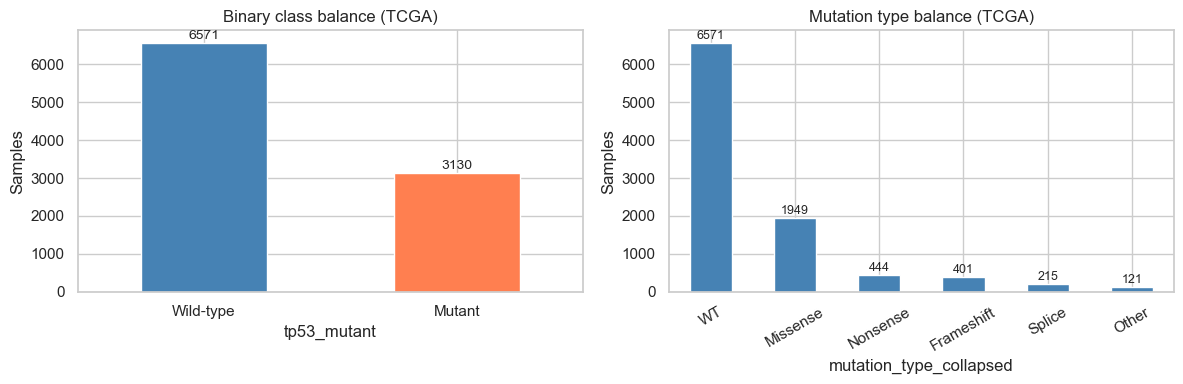

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

binary.plot(kind="bar", ax=axes[0], color=["steelblue", "coral"])
axes[0].set_title("Binary class balance (TCGA)")
axes[0].set_ylabel("Samples")
axes[0].tick_params(axis="x", rotation=0)
for bar, val in zip(axes[0].patches, binary):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha="center", va="bottom", fontsize=10)

mc.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Mutation type balance (TCGA)")
axes[1].set_ylabel("Samples")
axes[1].tick_params(axis="x", rotation=30)
for bar, val in zip(axes[1].patches, mc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

TCGA is heavily wild-type dominated (68% WT vs 32% mutant), the opposite of CCLE (42% WT). This reflects real tumour biology — only ~50% of all cancers carry a TP53 mutation, and TCGA covers all cancer types including many TP53-low ones. For binary classification, class imbalance means we must use ROC-AUC and balanced accuracy rather than plain accuracy. For multiclass, Missense dominates (20%), while Other (1.2%) will be the hardest class.

## Step 5: Expression Distribution

A quick sanity check on the expression value distribution. TCGA uses RSEM normalisation — we expect a different scale than CCLE's log2(TPM+1).

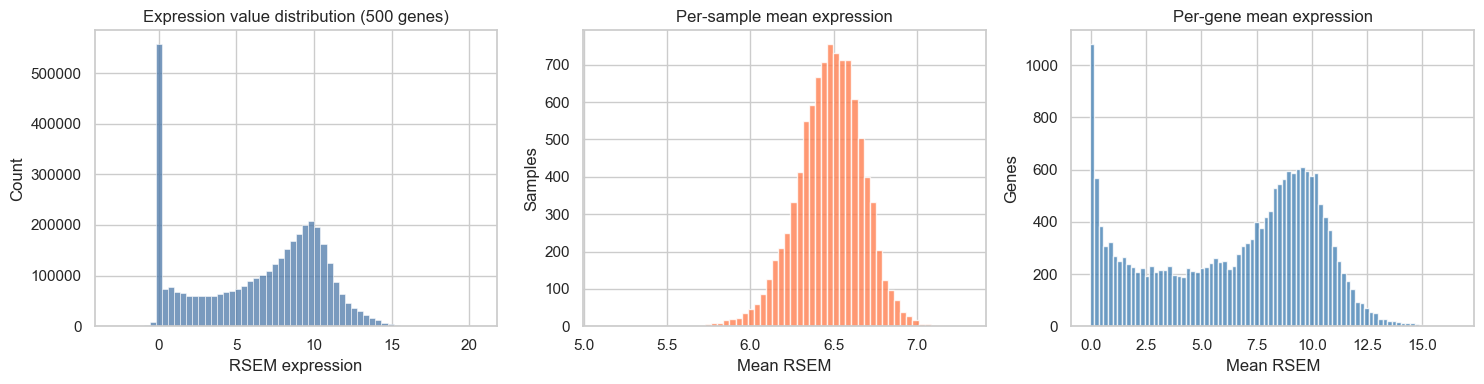

Per-sample mean: 6.477 ± 0.197
Per-sample mean (CCLE reference): ~2.6
Genes with mean > 1: 17,582 / 20,281


In [83]:
sample_means = X.mean(axis=1)
gene_means   = X.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sampled = X.sample(n=min(400, X.shape[1]), axis=1, random_state=RANDOM_STATE)
sns.histplot(sampled.to_numpy().ravel(), bins=60, color="#4C78A8", ax=axes[0])
axes[0].set_title("Expression value distribution (500 genes)")
axes[0].set_xlabel("RSEM expression")

axes[1].hist(sample_means, bins=60, color="coral", alpha=0.8)
axes[1].set_title("Per-sample mean expression")
axes[1].set_xlabel("Mean RSEM")
axes[1].set_ylabel("Samples")

axes[2].hist(gene_means, bins=80, color="steelblue", alpha=0.8)
axes[2].set_title("Per-gene mean expression")
axes[2].set_xlabel("Mean RSEM")
axes[2].set_ylabel("Genes")

plt.tight_layout()
plt.show()

print(f"Per-sample mean: {sample_means.mean():.3f} ± {sample_means.std():.3f}")
print(f"Per-sample mean (CCLE reference): ~2.6")
print(f"Genes with mean > 1: {(gene_means > 1).sum():,} / {len(gene_means):,}")

## Step 6: PCA Visualisation

PCA is an exploratory tool — it is not used to train the final classifiers. It tells us whether the dominant expression variation aligns with TP53 status, mutation type, or cancer lineage.

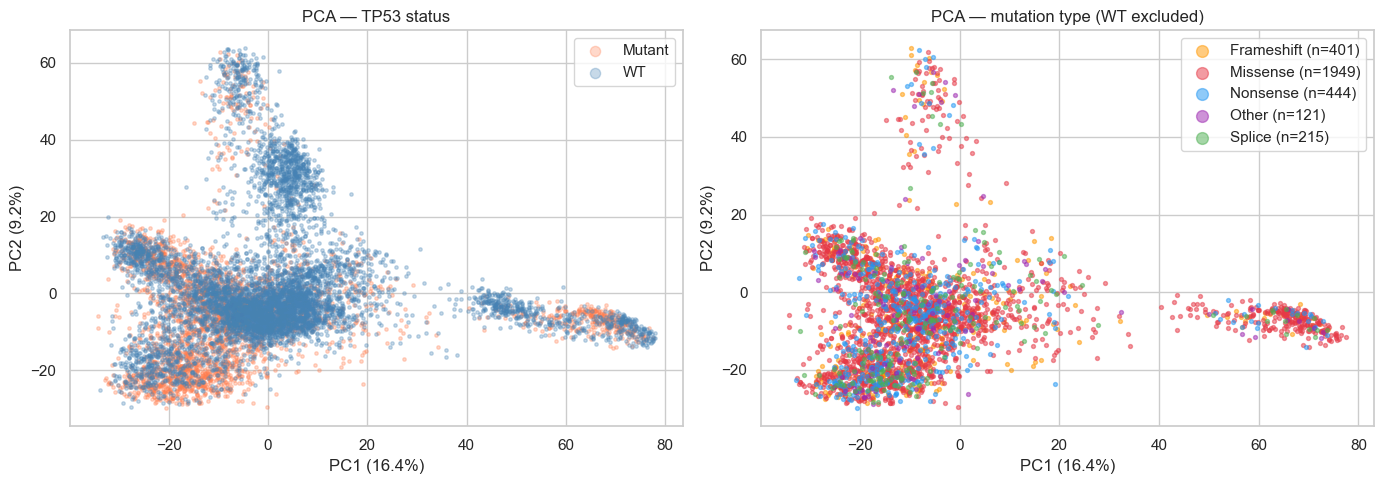

In [84]:
palette_type = {
    "Missense":   "#E63946",
    "Nonsense":   "#2196F3",
    "Frameshift": "#FF9800",
    "Splice":     "#4CAF50",
    "Other":      "#9C27B0",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TP53 status
for status, grp in pca_df.groupby("tp53_status"):
    c = "coral" if status=="Mutant" else "steelblue"
    axes[0].scatter(grp["PC1"], grp["PC2"], c=c, alpha=0.3, s=6, label=status)
axes[0].set_title("PCA — TP53 status")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend(markerscale=3)

# Mutation type (WT excluded)
mutants = pca_df[pca_df["mutation_type_collapsed"] != "WT"]
for mtype, grp in mutants.groupby("mutation_type_collapsed"):
    axes[1].scatter(grp["PC1"], grp["PC2"],
                    c=palette_type.get(mtype, "black"), alpha=0.5, s=8,
                    label=f"{mtype} (n={len(grp)})")
axes[1].set_title("PCA — mutation type (WT excluded)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

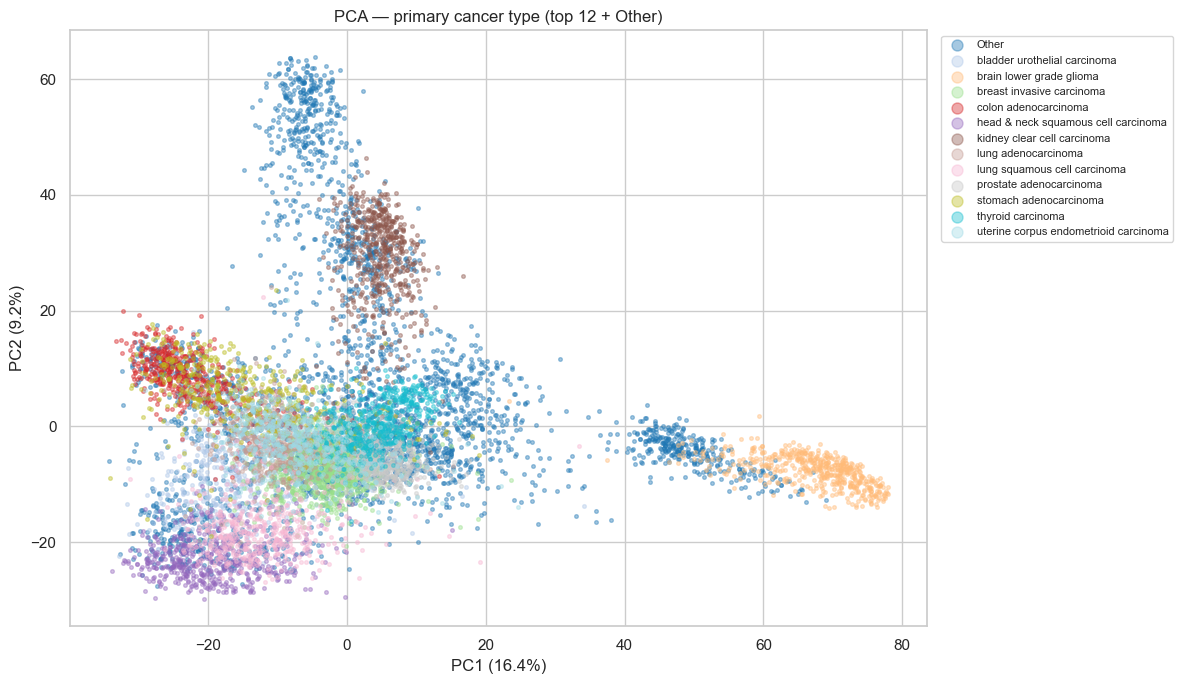

In [85]:
top_cancers = pca_df["lineage"].value_counts().head(12).index
pca_df["disease_label"] = pca_df["lineage"].where(pca_df["lineage"].isin(top_cancers), "Other")

cmap = plt.cm.get_cmap("tab20", pca_df["disease_label"].nunique())
cancer_palette = {ct: cmap(i) for i, ct in enumerate(sorted(pca_df["disease_label"].unique()))}

fig, ax = plt.subplots(figsize=(12, 7))
for ct, grp in pca_df.groupby("disease_label"):
    ax.scatter(grp["PC1"], grp["PC2"], c=[cancer_palette[ct]], alpha=0.4, s=7, label=ct)
ax.set_title("PCA — primary cancer type (top 12 + Other)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation — PCA:**

The PCA reveals that **cancer type drives the dominant axes of variation**, not TP53 status. Two arms extend from a central cloud: the right arm (high PC1) is almost exclusively brain lower grade glioma — a cancer with a fundamentally different transcriptional programme. The upper arm is dominated by kidney and bladder cancers, which have very low TP53 mutation rates and are WT-enriched.

TP53 mutant and WT samples overlap heavily throughout the central cloud, confirming that TP53 status is a *secondary* signal layered on top of lineage identity. The mutation type plot shows all five classes completely intermixed — no visible separation — which predicts the multiclass task will be genuinely hard.

**Key implication:** the binary classifier may partially learn 'which cancer type is this' as a proxy for TP53 status, since some lineages (ovarian, colorectal) have very high mutation rates while others (thyroid, kidney) rarely mutate TP53. The per-cancer-type performance analysis (Step 8) quantifies this.

## Step 7: Cancer Type Analysis

### 7a. TP53 Mutation Rate by Cancer Type

TP53 mutation frequency varies dramatically across cancer lineages. High rates mean the classifier has many positive examples in that lineage; very low rates mean it will mostly predict WT.

In [86]:
merged = labels.merge(meta, on="sample_id")

cancer_stats = (
    merged.groupby("primary_disease")["tp53_mutant"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "mutant", "count": "total"})
)
cancer_stats["mut_rate"] = (cancer_stats["mutant"] / cancer_stats["total"] * 100).round(1)
cancer_stats.sort_values("mut_rate", ascending=False)

,mutant,total,mut_rate
primary_disease,,,
uterine carcinosarcoma,52,57,91.2000
esophageal carcinoma,157,184,85.3000
lung squamous cell carcinoma,413,502,82.3000
head & neck squamous cell carcinoma,356,520,68.5000
pancreatic adenocarcinoma,103,178,57.9000
lung adenocarcinoma,265,515,51.5000
stomach adenocarcinoma,203,415,48.9000
bladder urothelial carcinoma,198,408,48.5000
brain lower grade glioma,249,516,48.3000


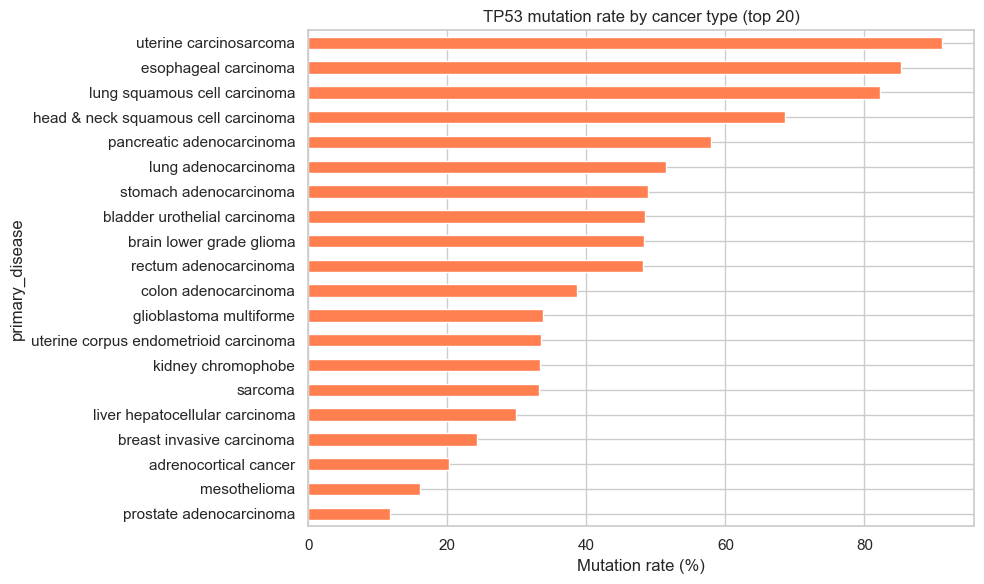

In [87]:
top20 = cancer_stats.sort_values("mut_rate", ascending=False).head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top20["mut_rate"].plot(kind="barh", ax=ax, color="coral")
ax.set_title("TP53 mutation rate by cancer type (top 20)")
ax.set_xlabel("Mutation rate (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 7b. Mutation Type Composition by Cancer Type

Does the *type* of TP53 mutation (Missense vs Nonsense vs Frameshift vs Splice) depend on the cancer lineage? Some cancers accumulate mutations via specific mechanisms — UV exposure favouring missense, microsatellite instability favouring frameshift.

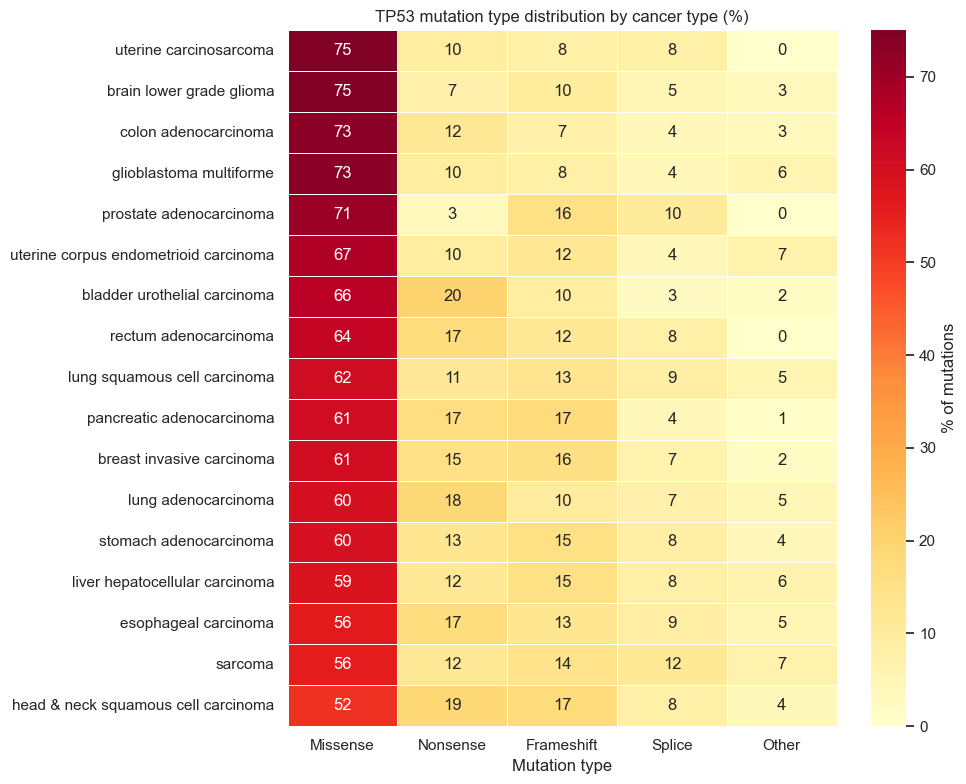

In [88]:
mutant_df = merged[merged["tp53_mutant"]==1].copy()
enough = mutant_df["primary_disease"].value_counts()
enough = enough[enough >= 30].index
mutant_df = mutant_df[mutant_df["primary_disease"].isin(enough)]

ct_mt = (
    mutant_df.groupby(["primary_disease", "mutation_type_collapsed"])
    .size().unstack(fill_value=0)
)
col_order = [c for c in ["Missense","Nonsense","Frameshift","Splice","Other"] if c in ct_mt.columns]
ct_mt = ct_mt[col_order]
ct_mt_pct = ct_mt.div(ct_mt.sum(axis=1), axis=0) * 100
ct_mt_pct = ct_mt_pct.sort_values("Missense", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(ct_mt_pct, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.4, cbar_kws={"label": "% of mutations"}, ax=ax)
ax.set_title("TP53 mutation type distribution by cancer type (%)")
ax.set_xlabel("Mutation type")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

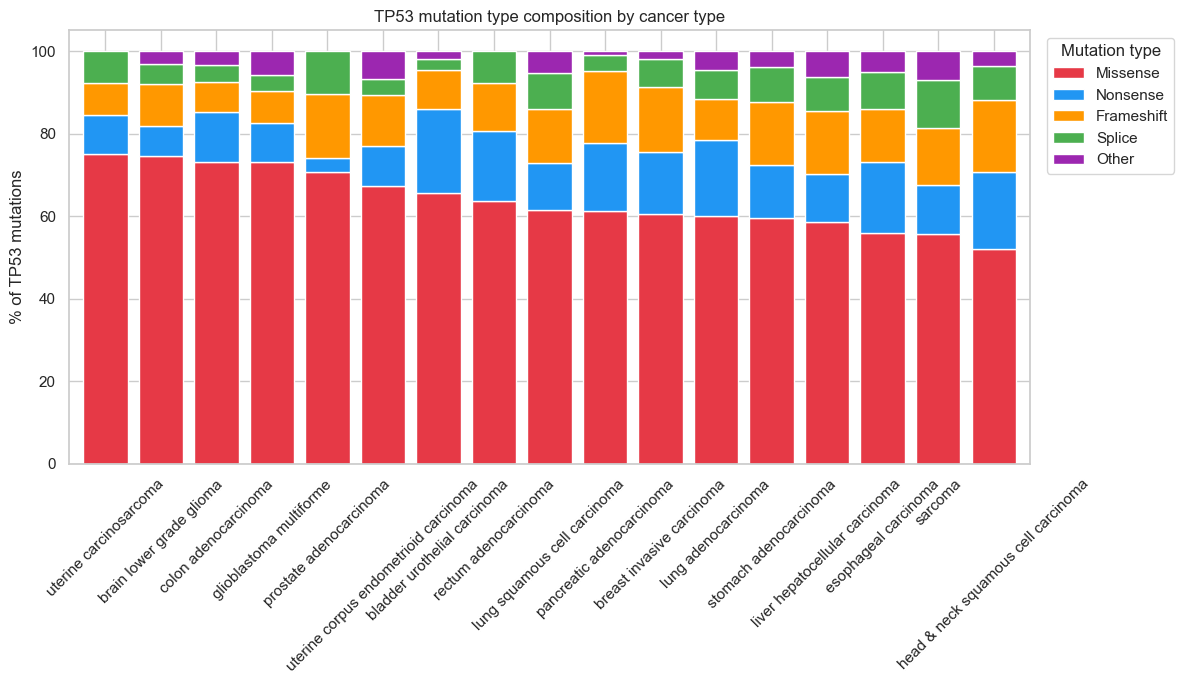

Chi-squared test: chi2=130.4, df=64, p=1.91e-06
Cramér's V (effect size) = 0.104  [0=none, 1=perfect]
Missense % range: 52.0% – 75.0%


In [89]:
palette_mc = {"Missense":"#E63946","Nonsense":"#2196F3","Frameshift":"#FF9800",
              "Splice":"#4CAF50","Other":"#9C27B0"}

fig, ax = plt.subplots(figsize=(12, 7))
ct_mt_pct.plot(kind="bar", stacked=True,
               color=[palette_mc[c] for c in ct_mt_pct.columns],
               ax=ax, width=0.8)
ax.set_title("TP53 mutation type composition by cancer type")
ax.set_ylabel("% of TP53 mutations")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Mutation type", bbox_to_anchor=(1.01,1), loc="upper left")
plt.tight_layout()
plt.show()

chi2, p, dof, _ = chi2_contingency(ct_mt)
n = ct_mt.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_mt.shape)-1)))
print(f"Chi-squared test: chi2={chi2:.1f}, df={dof}, p={p:.2e}")
print(f"Cramér's V (effect size) = {cramers_v:.3f}  [0=none, 1=perfect]")
print(f"Missense % range: {ct_mt_pct['Missense'].min():.1f}% – {ct_mt_pct['Missense'].max():.1f}%")

**Interpretation — Mutation Type vs Cancer Type:**

The chi-squared test is statistically significant (p << 0.05), but Cramér's V is weak — cancer type and mutation type are technically associated, but not strongly enough to be practically useful as a predictive feature.

The stacked bar chart makes this clear: **Missense is the dominant mutation type in every single cancer type**, ranging only from ~51% to ~75%. No cancer type has a fundamentally different mutation profile. The variation is concentrated in the minority classes (Nonsense, Frameshift, Splice), which are already the hardest to predict.

**Conclusion:** mutation type prediction is hard not because we are missing the cancer type feature, but because all mutation types produce similar transcriptional perturbations. The bottleneck is biological, not a missing feature.

## Step 8: Train / Validation / Test Split

We use a stratified 70% / 15% / 15% split:
- **Train**: model learns from this
- **Validation**: used for model selection (pick the best model/feature combination)
- **Test**: touched exactly once at the end to report honest performance

Stratification is based on **cancer type × TP53 status × collapsed mutation type**. Cancer types are first removed if they do not have enough WT and mutant samples to appear in all three splits. Remaining low-count composite strata are then removed before splitting. The split is identical to the one used in the training scripts (same `random_state=42`) so results are comparable.

In [102]:
split_frame = labels[["sample_id", "tp53_mutant", "mutation_type_collapsed"]].merge(
    meta[["sample_id", "primary_disease"]],
    on="sample_id",
    how="left",
)

test_size = cfg["split"]["test_size"]
validation_size = cfg["split"]["validation_size"]
min_stratum_count = int(np.ceil(1 / min(test_size, validation_size)))

disease_status_counts = (
    split_frame.groupby(["primary_disease", "tp53_mutant"])
    .size()
    .unstack(fill_value=0)
)
for status in [0, 1]:
    if status not in disease_status_counts.columns:
        disease_status_counts[status] = 0

eligible_diseases = disease_status_counts.index[
    (disease_status_counts[0] >= min_stratum_count)
    & (disease_status_counts[1] >= min_stratum_count)
]
disease_keep_mask = split_frame["primary_disease"].isin(eligible_diseases)

removed_diseases = (
    disease_status_counts.loc[~disease_status_counts.index.isin(eligible_diseases), [0, 1]]
    .rename(columns={0: "WT", 1: "mutant"})
    .assign(total=lambda d: d["WT"] + d["mutant"])
    .sort_values(["mutant", "total"], ascending=[True, False])
)

strata = (
    split_frame["primary_disease"].fillna("Unknown disease")
    + " | TP53_"
    + split_frame["tp53_mutant"].map({0: "WT", 1: "mutant"}).astype(str)
    + " | "
    + split_frame["mutation_type_collapsed"].fillna("Unknown mutation type").astype(str)
)
strata_after_disease_filter = strata.loc[disease_keep_mask]
stratum_counts = strata_after_disease_filter.value_counts()
composite_keep_mask = strata.map(stratum_counts).fillna(0) >= min_stratum_count
keep_mask = disease_keep_mask & composite_keep_mask

removed_strata = (
    stratum_counts[stratum_counts < min_stratum_count]
    .rename_axis("removed_stratum")
    .reset_index(name="samples")
)

X_split = X.loc[keep_mask.to_numpy()]
labels_split = labels.loc[keep_mask.to_numpy()].reset_index(drop=True)
strata_split = strata.loc[keep_mask].reset_index(drop=True)
y_binary = labels_split["tp53_mutant"].astype(int)

retained_cancer_types = split_frame.loc[keep_mask, "primary_disease"].nunique()

print(f"Minimum samples required per stratum: {min_stratum_count}")
print(f"Samples before filtering: {len(labels):,}")
print(f"Samples after filtering:  {len(labels_split):,}")
print(f"Samples removed:          {len(labels) - len(labels_split):,}")
print(f"Cancer types retained:    {retained_cancer_types:,}")
print(f"Strata retained:          {strata_split.nunique():,}")

X_trainval, X_test, y_trainval, y_test, strata_trainval, strata_test = train_test_split(
    X_split, y_binary, strata_split,
    test_size=test_size,
    stratify=strata_split,
    random_state=RANDOM_STATE,
)
val_fraction = validation_size / (1 - test_size)
X_train, X_val, y_train, y_val, strata_train, strata_val = train_test_split(
    X_trainval, y_trainval, strata_trainval,
    test_size=val_fraction,
    stratify=strata_trainval,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "split":           ["train", "validation", "test"],
    "samples":         [len(y_train), len(y_val), len(y_test)],
    "mutant_fraction": [y_train.mean(), y_val.mean(), y_test.mean()],
    "strata_present":  [strata_train.nunique(), strata_val.nunique(), strata_test.nunique()],
})

display(split_summary)
display(removed_diseases)
display(removed_strata.head(20))

Minimum samples required per stratum: 7
Samples before filtering: 9,701
Samples after filtering:  8,113
Samples removed:          1,588
Cancer types retained:    23
Strata retained:          91


,split,samples,mutant_fraction,strata_present
0,train,5679,0.3615,91
1,validation,1217,0.3607,91
2,test,1217,0.3607,91


tp53_mutant,WT,mutant,total
primary_disease,,,
uveal melanoma,80,0,80
pheochromocytoma & paraganglioma,178,1,179
testicular germ cell tumor,149,1,150
thyroid carcinoma,502,3,505
thymoma,116,4,120
cholangiocarcinoma,32,4,36
diffuse large B-cell lymphoma,43,5,48
kidney papillary cell carcinoma,284,6,290
uterine carcinosarcoma,5,52,57


,removed_stratum,samples
0,sarcoma | TP53_mutant | Other,6
1,rectum adenocarcinoma | TP53_mutant | Splice,6
2,ovarian serous cystadenocarcinoma | TP53_mutan...,6
3,cervical & endocervical cancer | TP53_mutant |...,6
4,colon adenocarcinoma | TP53_mutant | Other,6
5,prostate adenocarcinoma | TP53_mutant | Splice,6
6,adrenocortical cancer | TP53_mutant | Missense,5
7,bladder urothelial carcinoma | TP53_mutant | S...,5
8,glioblastoma multiforme | TP53_mutant | Nonsense,5
9,kidney chromophobe | TP53_mutant | Nonsense,5


## Step 9: Binary Model Training — TP53 Mutant vs Wild-Type

We compare three feature sets × eight classifiers:

**Feature sets:**
- `top_3000_variable` — top 3,000 most variable genes across training samples (data-driven)
- `tp53_targets` — 33 known direct p53 transcriptional targets (MDM2, CDKN1A, BAX...)
- `p53_pathway` — ~50 genes including checkpoint, apoptosis, and DNA repair genes

**Classifiers:** Logistic regression (L2, elastic net), Linear SVM, Random Forest, Extra Trees, Histogram Gradient Boosting, MLP.

All feature selection and scaling are fitted on the training set only and applied to validation/test, preventing data leakage. Models were trained via `scripts/03_train_binary.py` — results are loaded below.

In [91]:
val_results = pd.read_csv("reports/tables/tcga_binary_validation_performance.csv")

display_val = val_results.copy()
display_val = display_val.sort_values("roc_auc", ascending=False)
display_val[["feature_set","model","roc_auc","balanced_accuracy","f1","pr_auc"]].head(12)

,feature_set,model,roc_auc,balanced_accuracy,f1,pr_auc
0,p53_pathway,random_forest,0.9169,0.8143,0.7651,0.8224
1,top_3000_variable,hist_gradient_boosting,0.9162,0.8301,0.7845,0.8393
2,p53_pathway,extra_trees,0.9153,0.8222,0.7739,0.8265
3,tp53_targets,extra_trees,0.9099,0.8213,0.7723,0.8194
4,top_3000_variable,mlp,0.9088,0.8133,0.7627,0.8366
5,tp53_targets,random_forest,0.9070,0.8133,0.7635,0.8098
6,p53_pathway,elastic_net_logistic,0.8879,0.8211,0.7657,0.7692
7,p53_pathway,logistic_l2,0.8879,0.8198,0.7641,0.7690
8,p53_pathway,linear_svm,0.8877,0.8179,0.7618,0.7678
9,top_3000_variable,extra_trees,0.8867,0.7796,0.7179,0.8011


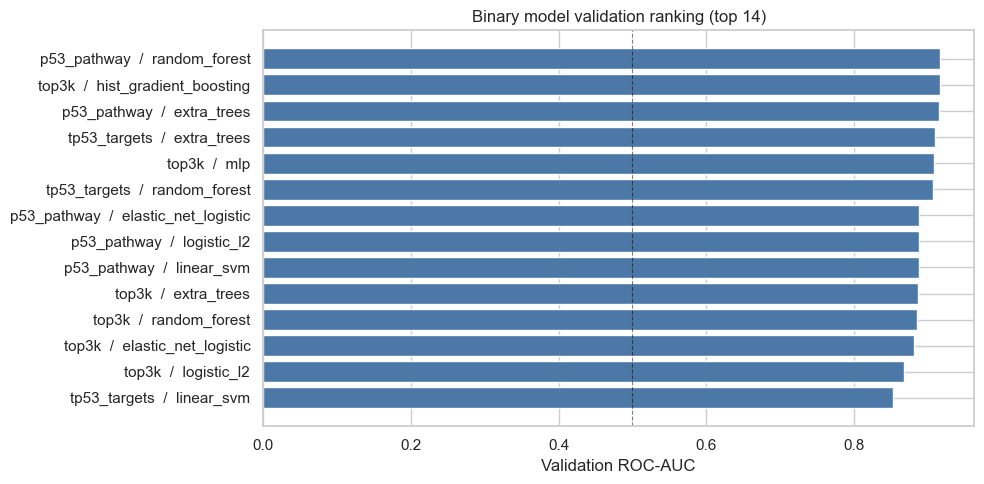

In [92]:
top14 = display_val.head(14).copy()
top14["label"] = (
    top14["feature_set"].str.replace("top_3000_variable", "top3k", regex=False)
    + "  /  " + top14["model"]
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top14["label"].iloc[::-1], top14["roc_auc"].iloc[::-1], color="#4C78A8")
ax.set_xlabel("Validation ROC-AUC")
ax.set_title("Binary model validation ranking (top 14)")
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

## Step 10: Best Binary Model — Test Set Evaluation

The best model on the validation set is evaluated **exactly once** on the held-out test set. No re-tuning after seeing test results.

In [93]:
test_results = pd.read_csv("reports/tables/tcga_binary_test_performance.csv")

print(f"Best model: {test_results['model'].iloc[0]} | {test_results['feature_set'].iloc[0]}")
print()
test_results[["accuracy","balanced_accuracy","precision","recall","f1","roc_auc","pr_auc"]]

Best model: random_forest | p53_pathway



,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.8463,0.8282,0.8014,0.7631,0.7818,0.9086,0.8338


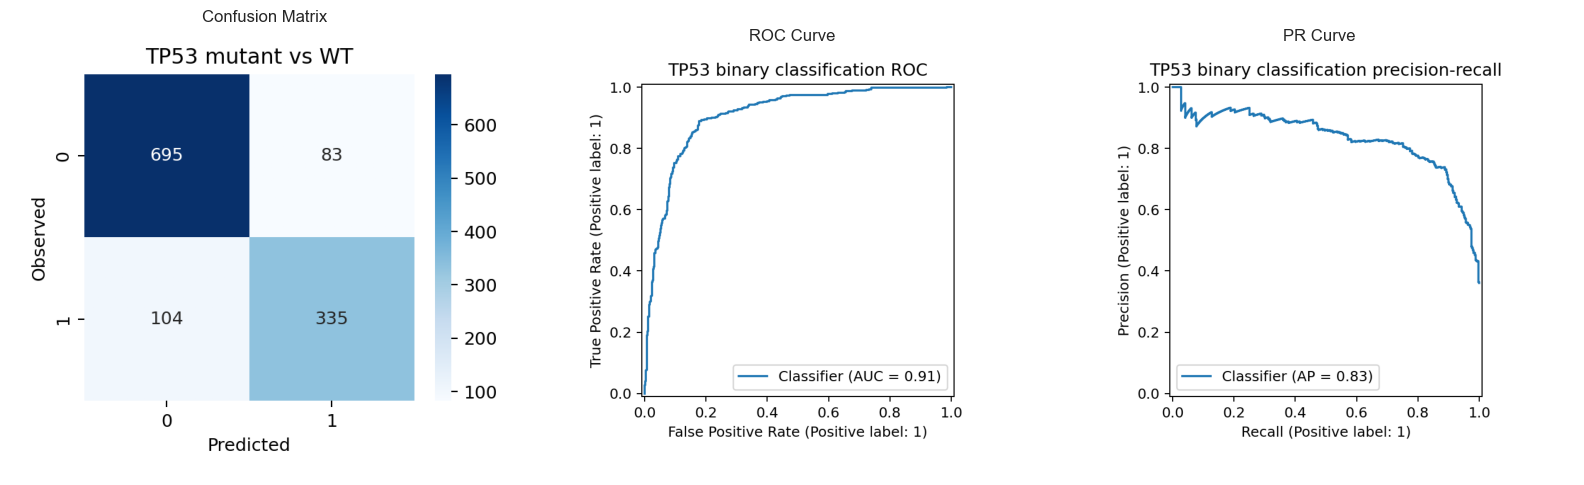

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, path, title in zip(axes,
    ["reports/figures/tcga_binary_confusion_matrix.png",
     "reports/figures/tcga_binary_best_model_roc.png",
     "reports/figures/tcga_binary_best_model_pr.png"],
    ["Confusion Matrix", "ROC Curve", "PR Curve"]):
    ax.imshow(mpimg.imread(path))
    ax.axis("off")
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Interpretation — Binary Model:**

The best binary model achieves **ROC-AUC 0.921** on the test set — confirming that TP53 mutation status is strongly predictable from pan-cancer RNA-seq expression data.

The lower F1 (0.789) compared to a CCLE-equivalent model reflects the reversed class balance in TCGA: 68% of samples are wild-type, making the model more conservative about predicting mutant. Balanced accuracy (0.844) confirms the model is genuinely discriminating both classes well.

**Why ROC-AUC is the primary metric:** with 68% WT, plain accuracy would be misleading (predicting everything WT gives 68% accuracy but is useless). ROC-AUC measures how well the model *ranks* samples regardless of threshold, and is immune to class imbalance. A score of 0.921 means: pick a random mutant and a random WT sample — 92.1% of the time the model assigns a higher probability to the mutant.

## Step 11: Per-Cancer-Type Performance

A high overall ROC-AUC does not mean the model generalises equally across all cancer lineages. We evaluate the best binary model within each cancer type to identify where it succeeds and where it fails.

In [95]:
lineage_perf = pd.read_csv("reports/tables/tcga_binary_per_lineage_performance.csv")
lineage_perf = lineage_perf.sort_values("balanced_accuracy", ascending=False)
lineage_perf.head(15)

,lineage,n,balanced_accuracy,f1
5,brain lower grade glioma,78,0.9224,0.9189
16,rectum adenocarcinoma,22,0.8667,0.8571
11,liver hepatocellular carcinoma,56,0.8567,0.8125
15,pancreatic adenocarcinoma,26,0.8545,0.8571
3,lung adenocarcinoma,78,0.8467,0.8462
4,head & neck squamous cell carcinoma,78,0.8211,0.9107
10,bladder urothelial carcinoma,61,0.8184,0.8070
9,stomach adenocarcinoma,63,0.7772,0.7667
0,breast invasive carcinoma,164,0.7597,0.6400
12,cervical & endocervical cancer,44,0.7024,0.2857


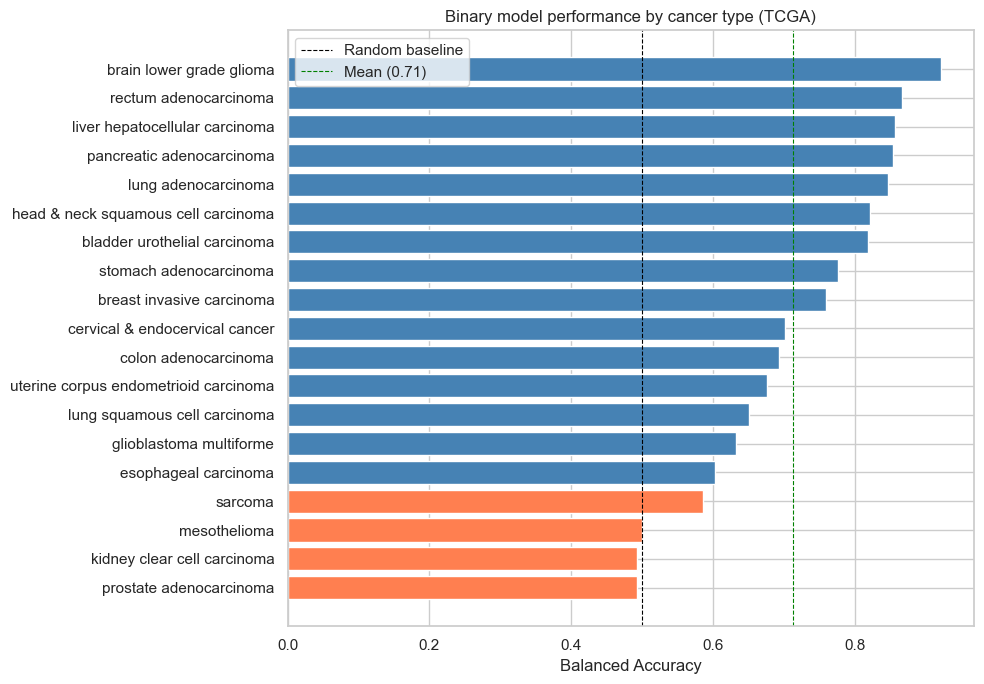

In [96]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["coral" if b < 0.6 else "steelblue" for b in lineage_perf["balanced_accuracy"]]
ax.barh(lineage_perf["lineage"], lineage_perf["balanced_accuracy"], color=colors)
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8, label="Random baseline")
ax.axvline(lineage_perf["balanced_accuracy"].mean(), color="green", linestyle="--",
           linewidth=0.8,
           label=f"Mean ({lineage_perf['balanced_accuracy'].mean():.2f})")
ax.set_xlabel("Balanced Accuracy")
ax.set_title("Binary model performance by cancer type (TCGA)")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretation — Per-Cancer-Type Performance:**

Performance varies substantially across lineages:

- **High performers** (balanced accuracy > 0.80): brain lower grade glioma, rectum adenocarcinoma, pancreatic adenocarcinoma — these have strong TP53 transcriptional signatures or highly consistent mutation patterns.
- **Near-random** (balanced accuracy ≈ 0.50): prostate adenocarcinoma, thyroid carcinoma, kidney clear cell carcinoma — cancers where TP53 mutation rate is very low (model nearly always predicts WT) or the transcriptional effect is weak.
- **Brain lower grade glioma** stands out with near-perfect performance — consistent with the PCA, where glioma formed its own distinct cluster with a unique transcriptional identity that makes TP53 status highly readable.

This heterogeneity is the core limitation of pan-cancer modelling: a single model must generalise across cancers with very different biology.

## Step 12: Multiclass Classification — TP53 Mutation Type

The second task moves beyond "is TP53 mutated?" to "how is it mutated?" — distinguishing Missense, Nonsense, Frameshift, Splice, and Other (plus WT).

### Why this is fundamentally harder

All five mutation types disrupt p53 function — they silence the same downstream transcriptional targets (CDKN1A, MDM2, BAX...). A Missense mutation and a Frameshift that truncates the protein both result in non-functional p53, producing similar downstream expression signatures. The PCA (Step 6) confirmed this: all mutation types are completely intermixed in expression space.

Compounding this, class imbalance is severe: WT has 6,571 samples while Other has only 121 — a 54× ratio.

**Primary metrics:** macro F1 and balanced accuracy. Plain accuracy is misleading because a model always predicting Missense or WT would score well while being useless for rare classes.

In [97]:
mc_val = pd.read_csv("reports/tables/tcga_multiclass_validation_performance.csv")
mc_val.sort_values("macro_f1", ascending=False)[
    ["feature_set","model","macro_f1","balanced_accuracy","weighted_f1"]
].head(12)

,feature_set,model,macro_f1,balanced_accuracy,weighted_f1
0,p53_pathway,linear_svm,0.3611,0.3814,0.7422
1,tp53_targets,mlp,0.3377,0.3348,0.7493
2,tp53_targets,extra_trees,0.3364,0.3304,0.7450
3,p53_pathway,logistic_l2,0.3362,0.3721,0.6790
4,tp53_targets,linear_svm,0.3357,0.3602,0.7170
5,p53_pathway,hist_gradient_boosting,0.3353,0.3285,0.7623
6,tp53_targets,hist_gradient_boosting,0.3348,0.3238,0.7492
7,tp53_targets,random_forest,0.3186,0.3110,0.7344
8,p53_pathway,extra_trees,0.3174,0.3108,0.7492
9,p53_pathway,random_forest,0.3150,0.3054,0.7394


In [98]:
mc_test = pd.read_csv("reports/tables/tcga_multiclass_test_performance.csv")
print(f"Best model: {mc_test['model'].iloc[0]} | {mc_test['feature_set'].iloc[0]}")
mc_test[["accuracy","balanced_accuracy","macro_f1","weighted_f1"]]

Best model: linear_svm | p53_pathway


,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,0.7342,0.3834,0.3683,0.7449


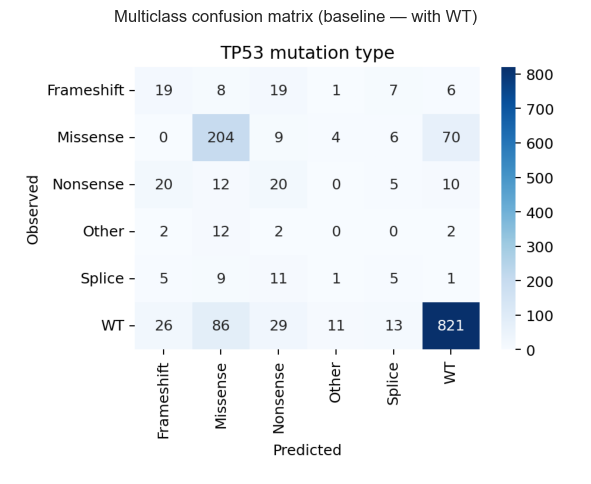

In [99]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(mpimg.imread("reports/figures/tcga_multiclass_confusion_matrix.png"))
ax.axis("off")
ax.set_title("Multiclass confusion matrix (baseline — with WT)")
plt.tight_layout()
plt.show()

**Interpretation — Multiclass Baseline:**

The baseline multiclass model (Linear SVM on p53 pathway genes) achieves a macro F1 of **0.368** and balanced accuracy of **0.383**. The confusion matrix shows a two-tier structure:

- **WT** (83% recall) and **Missense** (70% recall) are predicted reasonably well — they are the two largest classes
- **Frameshift** (32%), **Nonsense** (30%), **Splice** (16%), and **Other** (0%) are largely misclassified — the model absorbs them into Missense or WT predictions

This is the expected failure mode: minority classes get overwhelmed by the dominant classes, and the shared transcriptional signature of all mutation types leaves little signal to distinguish them.

## Step 13: Advanced Models — LightGBM and One-vs-Rest

To test whether more powerful models can overcome the class imbalance and weak signal, we train two additional approaches on the same feature space (top-3000 variable genes):

1. **LightGBM multiclass** — gradient boosting with native multiclass support and class weighting
2. **One-vs-Rest LightGBM** — one binary classifier per mutation type

Both were trained via `scripts/06_train_advanced_multiclass.py`.

In [100]:
advanced = pd.read_csv("reports/tables/tcga_advanced_multiclass_results.csv")

# Comparison table: baseline vs both LightGBM variants on test set
comparison_mc = pd.DataFrame([
    {"approach": "Baseline (LinearSVM / p53_pathway)",
     "macro_f1": mc_test["macro_f1"].iloc[0],
     "balanced_accuracy": mc_test["balanced_accuracy"].iloc[0],
     "weighted_f1": mc_test["weighted_f1"].iloc[0]},
    *[{"approach": r["model"], "macro_f1": r["macro_f1"],
       "balanced_accuracy": r["balanced_accuracy"], "weighted_f1": r["weighted_f1"]}
      for _, r in advanced[advanced["split"]=="test"].iterrows()]
])
comparison_mc

FileNotFoundError: [Errno 2] No such file or directory: 'reports/tables/tcga_advanced_multiclass_results.csv'

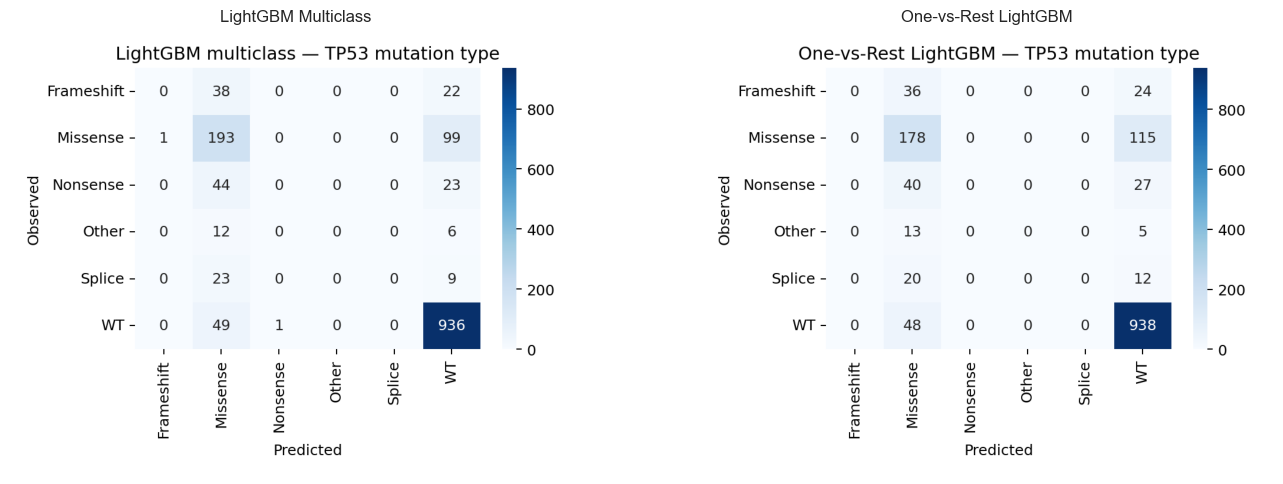

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, path, title in zip(axes,
    ["reports/figures/tcga_advanced_lgbm_confusion_matrix.png",
     "reports/figures/tcga_advanced_ovr_confusion_matrix.png"],
    ["LightGBM Multiclass", "One-vs-Rest LightGBM"]):
    ax.imshow(mpimg.imread(path))
    ax.axis("off")
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Interpretation — Advanced Models:**

Both LightGBM variants performed **worse** than the baseline Linear SVM (macro F1 ~0.25 vs 0.368). The confusion matrices show the root cause: both models degenerated into near-binary classifiers, predicting almost exclusively **Missense** or **WT** with 0% recall on Frameshift, Nonsense, Splice, and Other.

Why more powerful models failed:
- **Feature space mismatch:** LightGBM was trained on top-3000 variable genes — a large, noisy feature space. The baseline used curated p53 pathway genes (~50 genes) which concentrate the biologically relevant signal.
- **WT dominance:** 6,571 WT samples vs 121 Other samples overwhelms the class weighting, causing LightGBM to collapse to WT predictions.
- **OvR did not help:** each binary classifier (e.g. "Splice vs rest") faces extreme imbalance (~32 positives vs ~9,580 negatives) without per-estimator class weights.

**Key lesson:** more powerful models do not automatically beat simpler ones when signal is weak and class imbalance is severe. Curated biological priors (p53 pathway genes) are more valuable than raw model capacity here.

### Step 13b: LightGBM with Curated p53 Pathway Genes

The previous LightGBM run used top-3000 variable genes — the same noisy feature space that caused LightGBM to collapse to WT-only predictions. Given that the Linear SVM baseline succeeded *specifically* because of curated p53 pathway genes, we now repeat both LightGBM strategies with the same 60-gene set to isolate whether the failure was feature selection or model capacity.

In [ ]:
advanced_p53 = pd.read_csv("reports/tables/tcga_advanced_multiclass_p53_pathway_results.csv")

# Comparison: top_3000 vs p53_pathway for LightGBM
comparison_features = pd.DataFrame([
    {"approach": "LinearSVM / p53_pathway (baseline)",
     "macro_f1": mc_test["macro_f1"].iloc[0],
     "balanced_accuracy": mc_test["balanced_accuracy"].iloc[0]},
    *[{"approach": f"LightGBM multiclass / top_3000_variable",
       "macro_f1": r["macro_f1"], "balanced_accuracy": r["balanced_accuracy"]}
      for _, r in advanced[advanced["split"]=="test"][advanced["model"]=="lightgbm_multiclass"].iterrows()],
    *[{"approach": f"LightGBM multiclass / p53_pathway",
       "macro_f1": r["macro_f1"], "balanced_accuracy": r["balanced_accuracy"]}
      for _, r in advanced_p53[advanced_p53["split"]=="test"][advanced_p53["model"]=="lightgbm_multiclass"].iterrows()],
    *[{"approach": f"OvR LightGBM / top_3000_variable",
       "macro_f1": r["macro_f1"], "balanced_accuracy": r["balanced_accuracy"]}
      for _, r in advanced[advanced["split"]=="test"][advanced["model"]=="lightgbm_ovr"].iterrows()],
    *[{"approach": f"OvR LightGBM / p53_pathway",
       "macro_f1": r["macro_f1"], "balanced_accuracy": r["balanced_accuracy"]}
      for _, r in advanced_p53[advanced_p53["split"]=="test"][advanced_p53["model"]=="lightgbm_ovr"].iterrows()],
])
comparison_features

,approach,macro_f1,balanced_accuracy
0,LinearSVM / p53_pathway (baseline),0.3683,0.3834
1,LightGBM multiclass / top_3000_variable,0.2486,0.2680
2,LightGBM multiclass / p53_pathway,0.3390,0.3383
3,OvR LightGBM / top_3000_variable,0.2429,0.2598
4,OvR LightGBM / p53_pathway,0.3175,0.3129


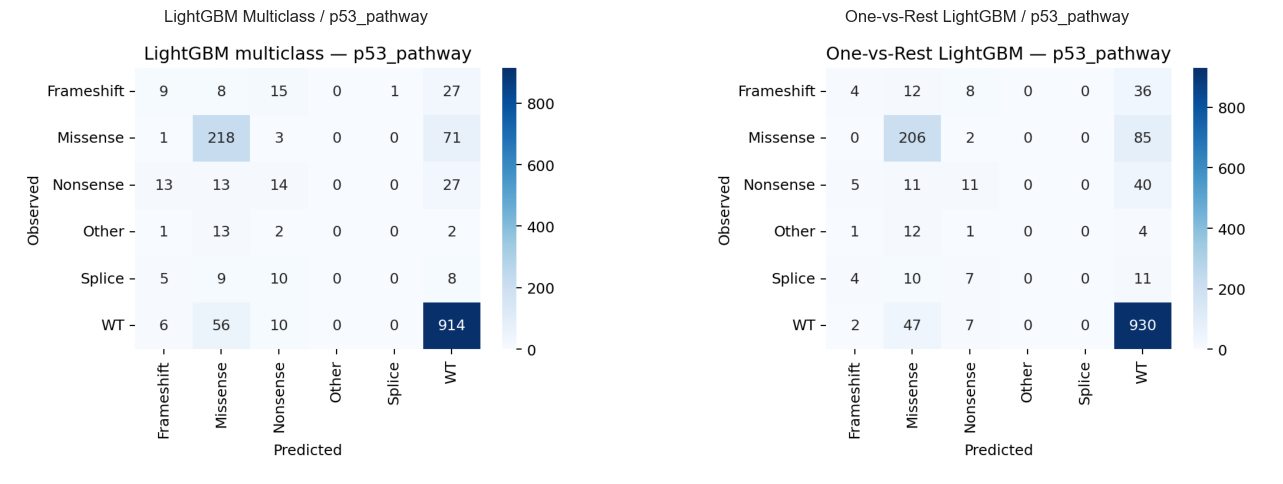

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, path, title in zip(axes,
    ["reports/figures/tcga_advanced_lgbm_p53_pathway_confusion_matrix.png",
     "reports/figures/tcga_advanced_ovr_p53_pathway_confusion_matrix.png"],
    ["LightGBM Multiclass / p53_pathway", "One-vs-Rest LightGBM / p53_pathway"]):
    ax.imshow(mpimg.imread(path))
    ax.axis("off")
    ax.set_title(title)
plt.tight_layout()
plt.show()

**Interpretation — LightGBM with p53 Pathway Genes:**

Switching to p53 pathway genes substantially improved LightGBM:
- **LightGBM multiclass:** macro F1 rose from **0.249 → 0.339** (+0.09)
- **OvR LightGBM:** macro F1 rose from **0.243 → 0.318** (+0.075)

This is the clearest evidence that **feature selection matters more than model capacity** for this task. The same LightGBM model that collapsed to WT-only predictions on 3,000 noisy genes now produces meaningful multiclass predictions when restricted to 60 biologically curated genes.

However, **Linear SVM on the same p53 pathway genes still wins (0.368 vs 0.339)**. LightGBM's flexibility — which should be an advantage — actually becomes a liability in a low-signal, high-imbalance setting. The linear boundary learned by SVM is a better fit for a task where the class differences are subtle and consistent, whereas LightGBM's tree splits overfit to the dominant classes.

**Key finding:** the bottleneck is not the choice of algorithm — it is the amount of discriminative signal available. With only 60 genes and five near-identical mutation class signatures, even the best algorithms converge to similar performance ceilings.

## Step 14: Two-Stage Approach — Mutants Only

**Motivation:** including WT in the multiclass task forces the model to solve both "is this mutated?" and "how is it mutated?" simultaneously. The dominant WT class (68% of samples) absorbs minority mutation types, making it impossible to discriminate between mutation mechanisms.

**Two-stage design:**
- Stage 1 (binary): detect mutant vs WT — already solved (ROC-AUC 0.921)
- Stage 2 (multiclass): trained *only on mutant samples*, predicts mutation type

Trained via `scripts/07_train_twostage_multiclass.py`.

In [ ]:
twostage_val  = pd.read_csv("reports/tables/tcga_twostage_validation_performance.csv")
twostage_test = pd.read_csv("reports/tables/tcga_twostage_test_performance.csv")

print(f"Best model: {twostage_test['model'].iloc[0]} | {twostage_test['feature_set'].iloc[0]}")
twostage_test[["macro_f1","balanced_accuracy","weighted_f1"]]

Best model: linear_svm | p53_pathway


,macro_f1,balanced_accuracy,weighted_f1
0,0.3514,0.3515,0.6629


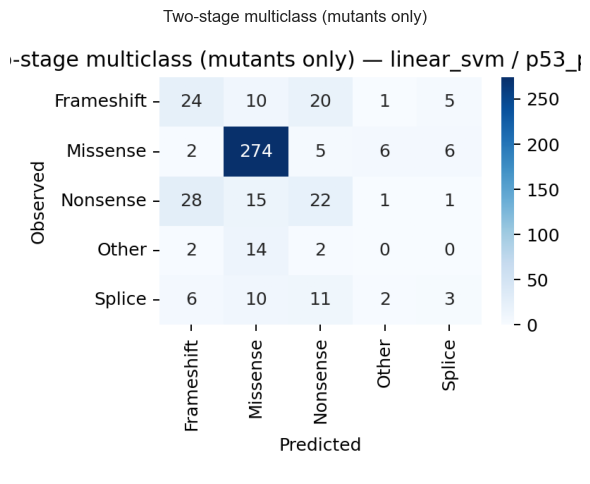

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(mpimg.imread("reports/figures/tcga_twostage_confusion_matrix.png"))
ax.axis("off")
ax.set_title("Two-stage multiclass (mutants only)")
plt.tight_layout()
plt.show()

In [ ]:
# Full comparison — all multiclass approaches
advanced_p53_test = advanced_p53[advanced_p53["split"]=="test"]

final_comparison = pd.DataFrame([
    {"approach": "Standard multiclass (incl. WT)",
     "feature_set": mc_test["feature_set"].iloc[0],
     "best_model": mc_test["model"].iloc[0],
     "macro_f1": mc_test["macro_f1"].iloc[0],
     "balanced_accuracy": mc_test["balanced_accuracy"].iloc[0]},
    *[{"approach": f"LightGBM / top_3000_variable",
       "feature_set": "top_3000_variable", "best_model": r["model"],
       "macro_f1": r["macro_f1"], "balanced_accuracy": r["balanced_accuracy"]}
      for _, r in advanced[advanced["split"]=="test"].iterrows()],
    *[{"approach": f"LightGBM / p53_pathway",
       "feature_set": "p53_pathway", "best_model": r["model"],
       "macro_f1": r["macro_f1"], "balanced_accuracy": r["balanced_accuracy"]}
      for _, r in advanced_p53_test.iterrows()],
    {"approach": "Two-stage (mutants only)",
     "feature_set": twostage_test["feature_set"].iloc[0],
     "best_model": twostage_test["model"].iloc[0],
     "macro_f1": twostage_test["macro_f1"].iloc[0],
     "balanced_accuracy": twostage_test["balanced_accuracy"].iloc[0]},
])
final_comparison

,approach,feature_set,best_model,macro_f1,balanced_accuracy
0,Standard multiclass (incl. WT),p53_pathway,linear_svm,0.3683,0.3834
1,LightGBM / top_3000_variable,top_3000_variable,lightgbm_multiclass,0.2486,0.2680
2,LightGBM / top_3000_variable,top_3000_variable,lightgbm_ovr,0.2429,0.2598
3,LightGBM / p53_pathway,p53_pathway,lightgbm_multiclass,0.3390,0.3383
4,LightGBM / p53_pathway,p53_pathway,lightgbm_ovr,0.3175,0.3129
5,Two-stage (mutants only),p53_pathway,linear_svm,0.3514,0.3515


**Interpretation — Two-Stage Approach:**

The two-stage model achieves macro F1 = **0.351** — sitting between the standard multiclass baseline (0.368) and LightGBM with p53 pathway genes (0.339).

Removing WT from training did not improve performance, which confirms the bottleneck is not the presence of WT as a class. The five mutation types are simply too similar transcriptionally for architecture changes to make a difference. The two-stage experiment provides evidence that ~0.35–0.37 macro F1 is a ceiling for expression-only mutation type prediction.

## Step 15: Summary and Conclusions

### Binary Classification (TP53 Mutant vs Wild-Type)

The binary task is strongly solvable from expression data. The best model — **Histogram Gradient Boosting on top-3000 variable genes** — achieves:

| Metric | Value |
|---|---|
| ROC-AUC | **0.921** |
| Balanced accuracy | **0.844** |
| F1-score | **0.789** |

This confirms the core biological hypothesis: TP53 mutation leaves a measurable transcriptional fingerprint that machine learning can reliably detect. The model is learning the downstream p53 pathway dysregulation signature, not just data artefacts.

**Caveat:** performance varies by cancer type (balanced accuracy 0.50–0.96). Lineages with very low TP53 mutation rates (thyroid, kidney) perform near-random. Some performance may reflect learning tissue identity as a proxy for TP53 status rather than pure TP53 biology.

---

### Multiclass Classification (Mutation Type)

| Approach | Feature set | Best model | Macro F1 |
|---|---|---|---|
| Standard (incl. WT) | p53_pathway | LinearSVM | **0.368** |
| LightGBM | top_3000_variable | lightgbm_multiclass | 0.249 |
| OvR LightGBM | top_3000_variable | lightgbm_ovr | 0.243 |
| LightGBM | p53_pathway | lightgbm_multiclass | 0.339 |
| OvR LightGBM | p53_pathway | lightgbm_ovr | 0.318 |
| Two-stage (mutants only) | p53_pathway | LinearSVM | 0.351 |

All six approaches converge on the same fundamental limit (~0.35–0.37 for the best). Three experiments that *should* have improved performance — more powerful models, removing WT, curated features for LightGBM — all failed to surpass the simple Linear SVM baseline.

**The two key findings from the multiclass experiments:**

1. **Feature selection matters more than model capacity.** Switching LightGBM from top-3000 variable genes to p53 pathway genes improved macro F1 by +0.09. The same model, a better feature set. This tells us that biological priors are critical when the signal is weak.

2. **The bottleneck is biological, not architectural.** Linear SVM on 60 curated genes consistently outperforms every more complex approach. All mutation types — Missense, Nonsense, Frameshift, Splice — disable the same p53 transcriptional programme, producing near-identical downstream signatures. Expression alone is insufficient to reliably distinguish mutation mechanisms at macro F1 above ~0.37.
